# Referencia, muestra negativa y locus de color

## TL;DR

- La referencia local contiene 705 WR del catálogo de Crowther v1.33; 442 tienen alias Gaia DR3 explícito.
- `relaxed_photometry` conserva 331/347 WR después del locus y reduce 66.787 negativos a 33.343.
- El locus usa seis planos intra-misión, HuberRegressor y `signed_log1p`; no usa colores cruzados entre misiones.
- La muestra SIMBAD es una colección controlada de contaminantes plausibles, no una estimación de toda la población no-WR.

## Contexto y método

La referencia se descarga como snapshot con fecha y SHA-256. Solo se incorporan al
pipeline reproducible las entradas que declaran un alias Gaia DR3; no se infiere
identidad a partir de coordenadas. Gaia se enriquece con 2MASS y AllWISE mediante
crossmatch oficial y, cuando falta una contraparte, mediante fallback VizieR con
proveniencia y separación angular conservadas.

Las variantes `strict` y `relaxed` exigen Gaia G/BP/RP, 2MASS J/H/Ks y WISE W1/W2.
`strict` admite calidad A en las bandas IR requeridas y `relaxed` admite A o B.

In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display
import pandas as pd

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)

from wr_detector.reporting.project_summary import (
    AP_LEADER_RESULT_ID,
    LEADING_RESULT_ID,
    STABLE_RESULT_ID,
    collect_evidence,
    generate_figures,
)

PUBLIC_DIR = PROJECT_ROOT / "reports" / "public"
FIGURE_DIR = PUBLIC_DIR / "figures"
evidence = collect_evidence()
figure_paths = generate_figures(evidence, FIGURE_DIR)
display(Markdown(f"**Snapshot local:** `{evidence.snapshot_date}`"))

**Snapshot local:** `2026-07-26`

## Datos

In [2]:
catalogue = pd.DataFrame(
    {
        "etapa": ["Catálogo WR", "Alias Gaia DR3", "Fotometría relaxed", "Locus keep"],
        "WR": [
            evidence.catalogue["catalogue_rows"],
            evidence.catalogue["gaia_alias_rows"],
            int(
                evidence.locus.loc[
                    (evidence.locus["variant"] == "relaxed_photometry")
                    & (evidence.locus["class"] == "WR"),
                    "rows",
                ].iloc[0]
            ),
            int(
                evidence.locus.loc[
                    (evidence.locus["variant"] == "relaxed_photometry")
                    & (evidence.locus["class"] == "WR"),
                    "locus_keep",
                ].iloc[0]
            ),
        ],
    }
)
display(catalogue)
display(
    evidence.negative_types.rename(
        columns={"object_group": "clase", "rows": "fuentes"}
    )
)

,etapa,WR
0,Catálogo WR,705
1,Alias Gaia DR3,442
2,Fotometría relaxed,347
3,Locus keep,331


,clase,fuentes
0,C*,10000
1,EmLine*,10000
2,LongPeriodV*,10000
3,RGB*,10000
4,YSO,10000
5,EclBin,9999
6,Eruptive*,5636
7,TTauri*,5597
8,AGB*,4813
9,Be*,2277


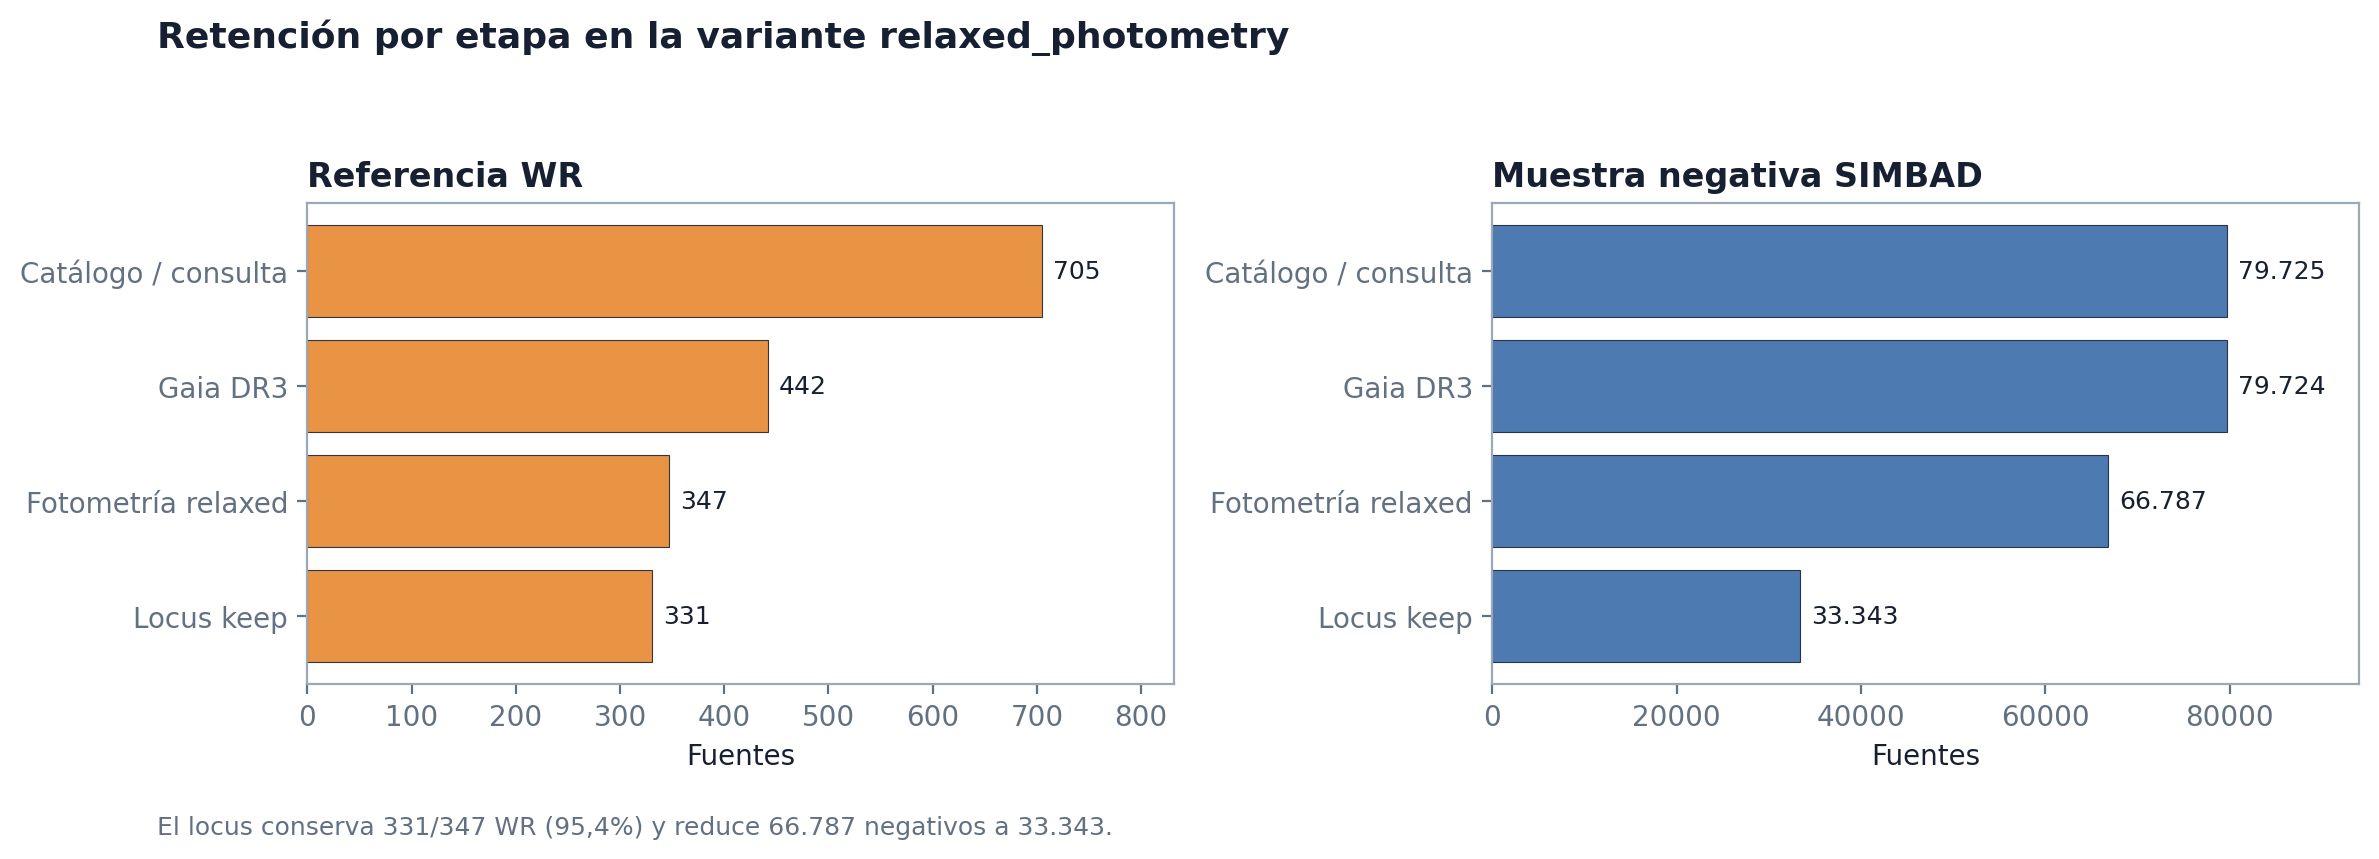

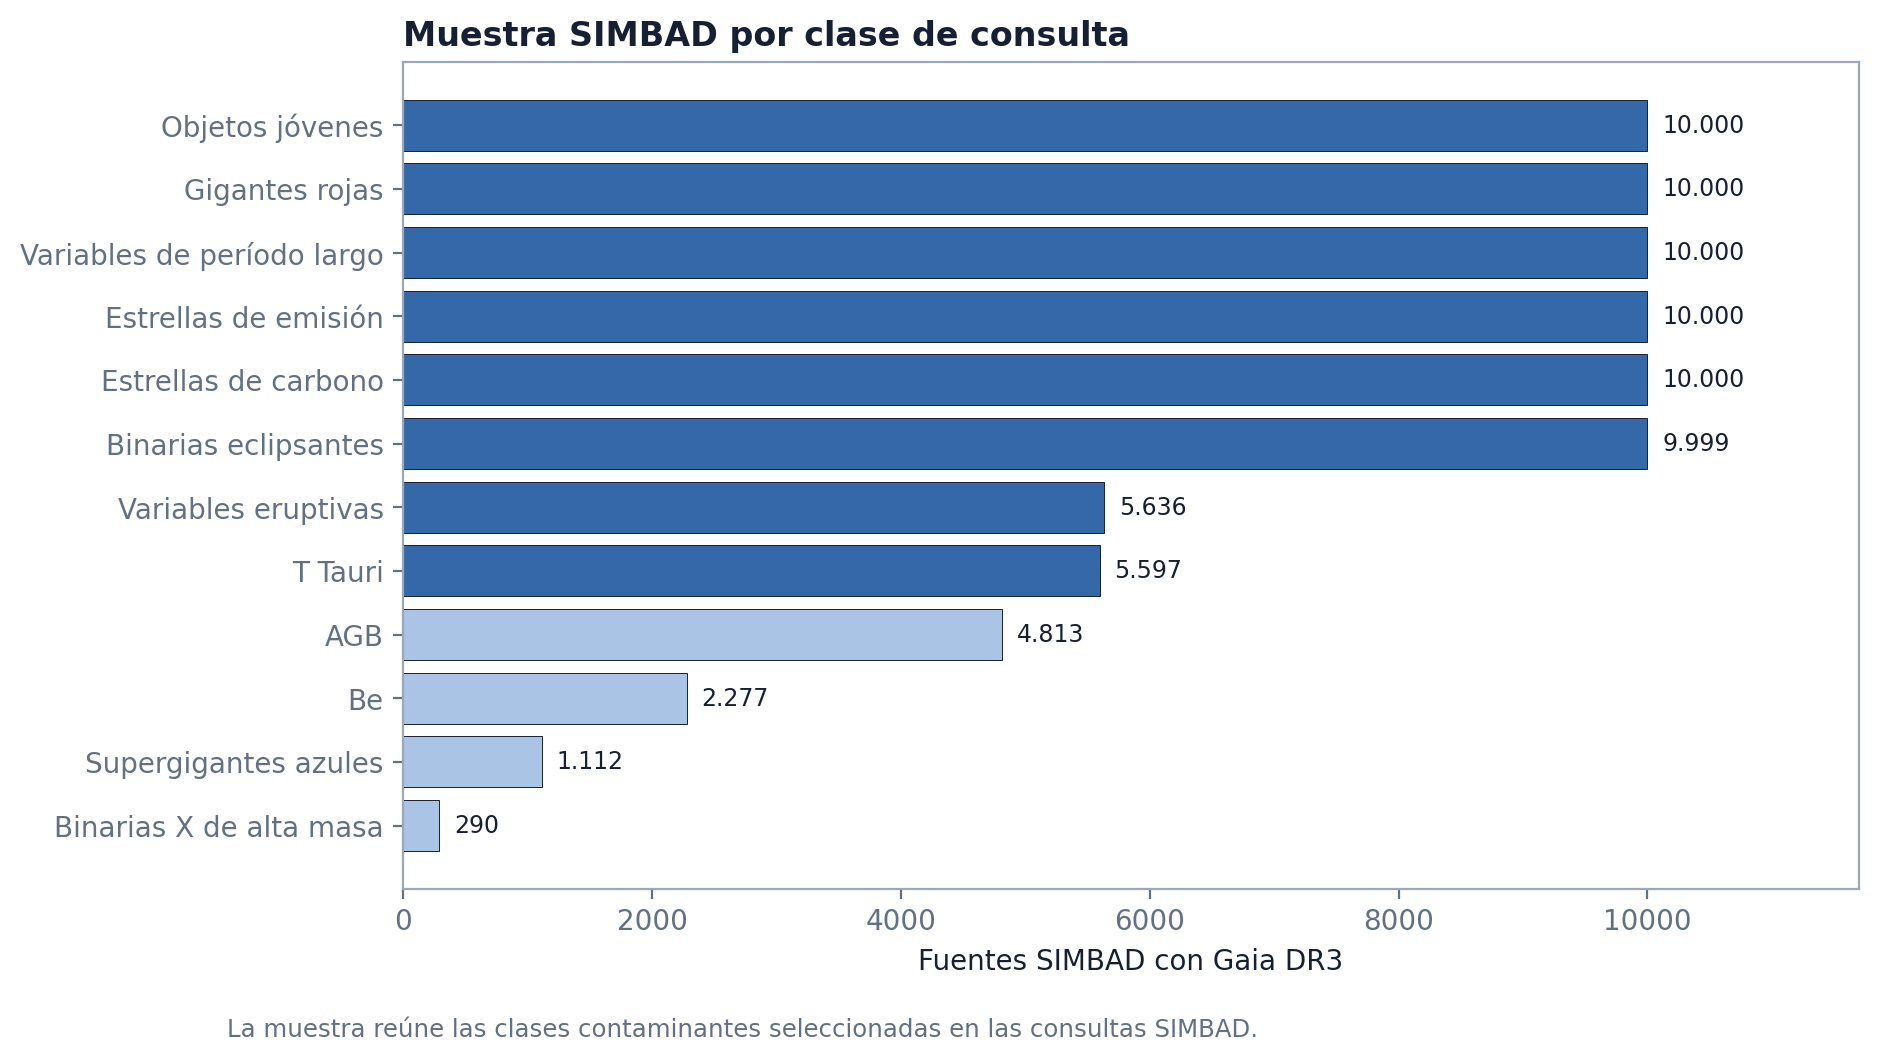

In [3]:
display(Image(filename=str(figure_paths["retention"]), width=1000))
display(Image(filename=str(figure_paths["negative_composition"]), width=900))

## Resultado: definición del locus

Para cada color \(c\):

\[
T(c)=\operatorname{sign}(c)\ln(1+|c|)
\]

En cada plano \((x,y)\) se ajusta:

\[
T(y_i)=\beta_0+\beta_1T(x_i)+\epsilon_i,\qquad
r_i=T(y_i)-[\beta_0+\beta_1T(x_i)]
\]

El umbral del plano es \(q_{0.975}(|r|)\) medido sobre WR. Una fuente se marca
como outlier agregado si excede el umbral en al menos dos de los seis planos.

La formulación anterior basada en `log10` de colores positivos exigía que los
seis colores fueran positivos simultáneamente. Solo 2/347 WR de
`relaxed_photometry` y 0/306 de `strict_photometry` cumplían esa condición.
`signed_log1p` conserva el signo, está definida en cero y permite usar todas las
filas finitas.

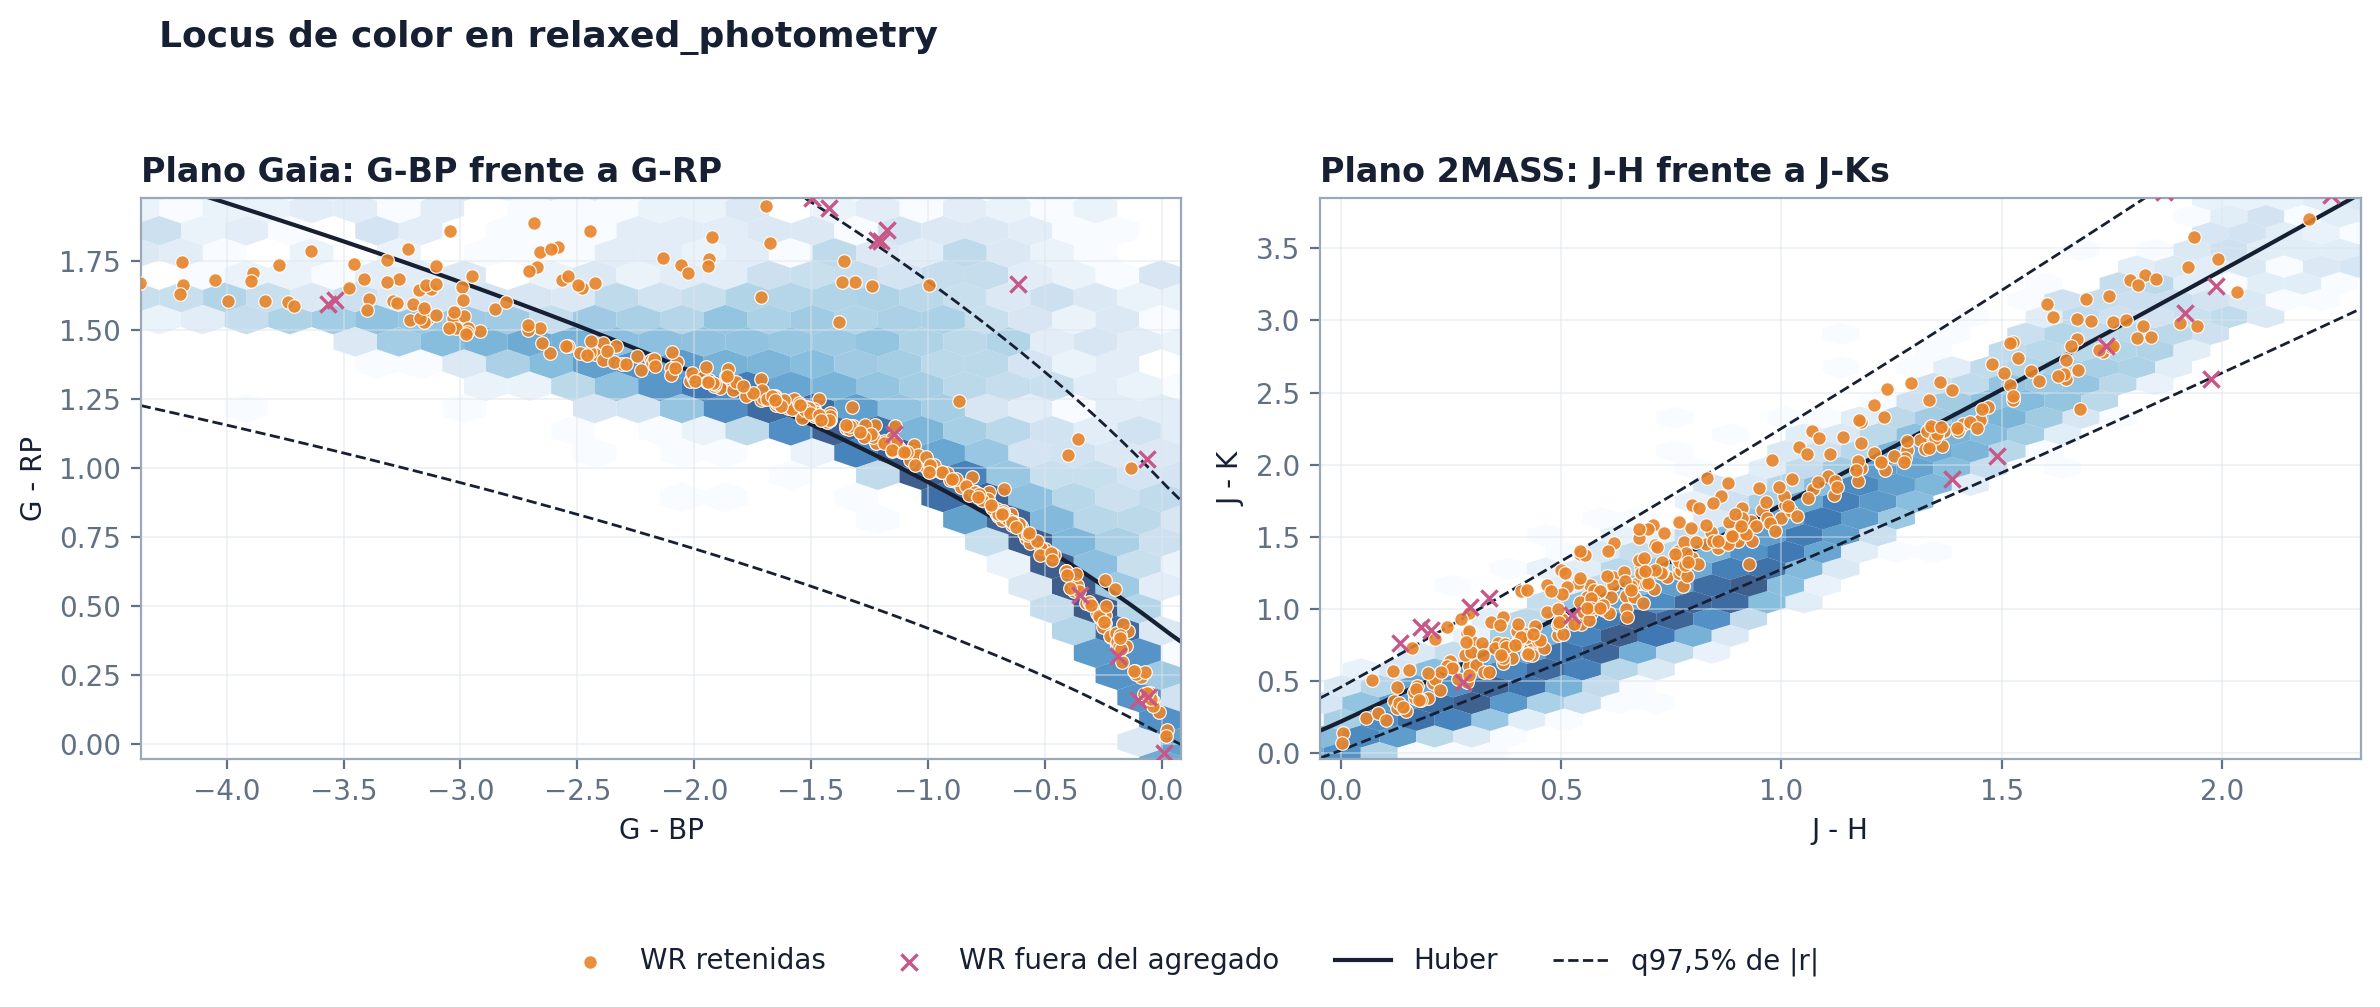

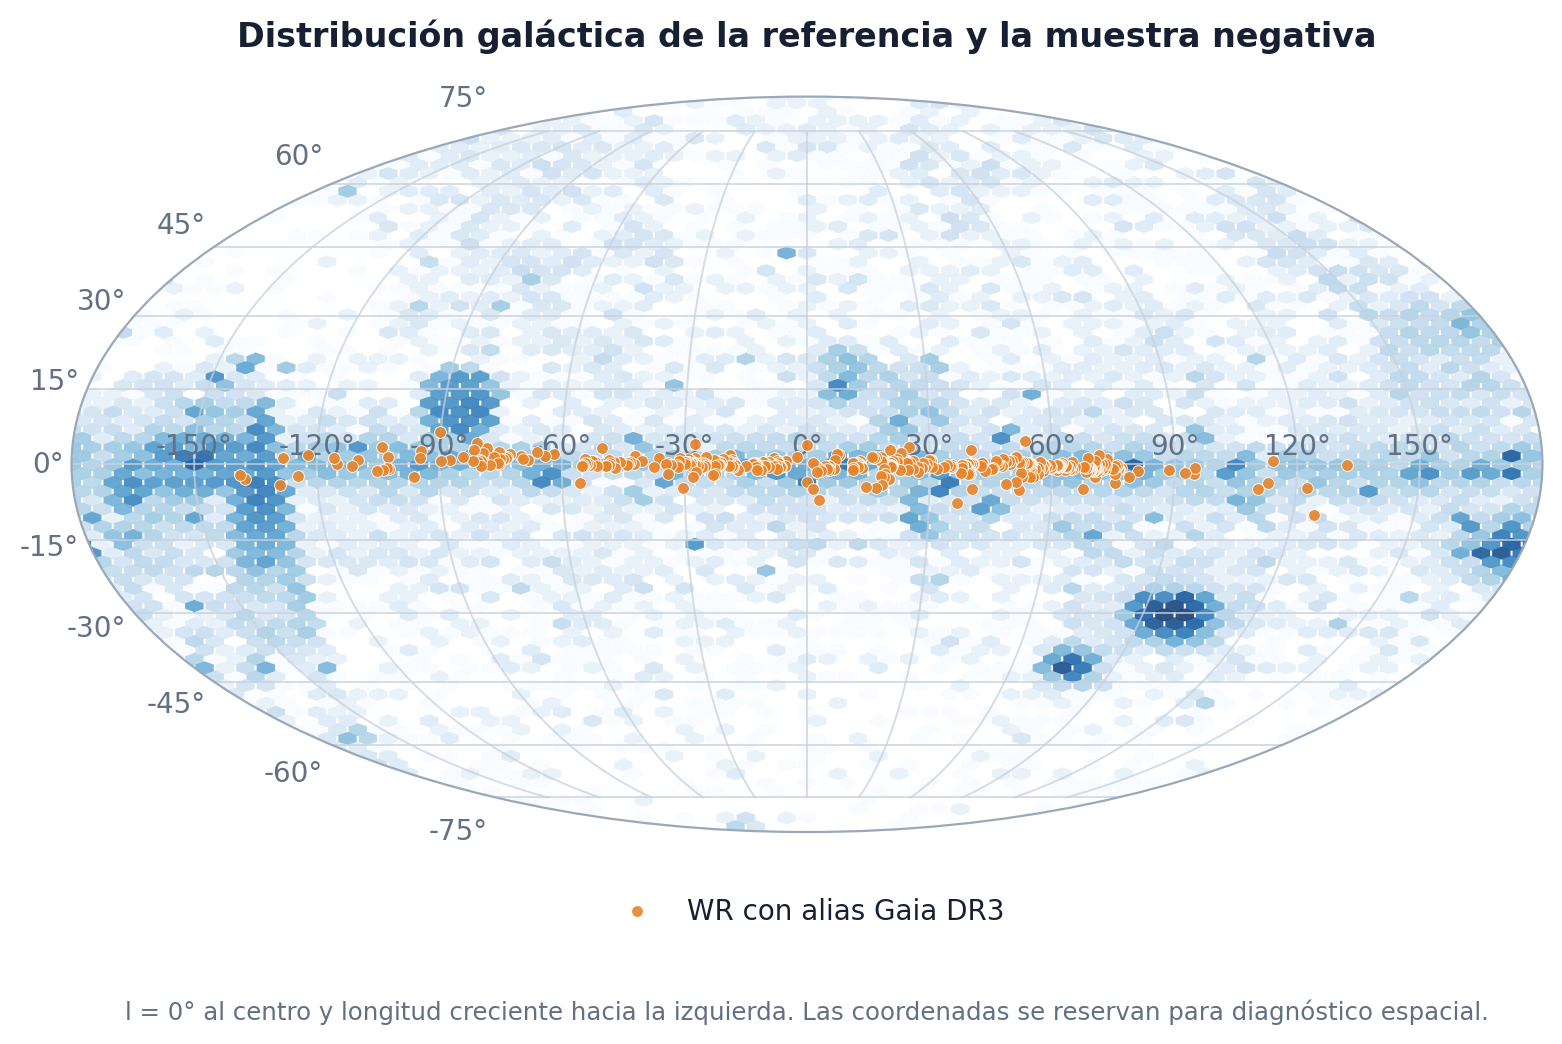

In [4]:
display(Image(filename=str(figure_paths["locus"]), width=1050))
display(Image(filename=str(figure_paths["sky"]), width=1000))

## Takeaways

El filtro define una región de compatibilidad fotométrica, no una ventana
geográfica del plano galáctico. Los colores cruzados entre Gaia, 2MASS y WISE se
excluyen para evitar que offsets de misión, calibración o crossmatch definan el
locus. W1-W2 sí se conserva como feature, pero WISE no genera un plano porque no
se usan W3/W4.

Los conteos y gráficos se regeneran desde DuckDB/Parquet mediante
`python -m wr_detector.reporting.project_summary`.